In [1]:
import numpy as np
import pandas as pd

from pint import UnitRegistry, set_application_registry



import pint_pandas

In [2]:
ureg = UnitRegistry() # auto_reduce_dimensions = True
ureg.formatter.default_format = "P"

set_application_registry(ureg)

ureg.setup_matplotlib()

In [3]:
import matplotlib.pyplot as plt


In [4]:
raw_data_set = pd.read_excel("data.xlsx")


In [5]:
speed_of_sound = 343.21 * ureg.meters / ureg.seconds

density_of_water = 1000 * ureg.kilogram / (ureg.meter**3)

In [6]:
bottle_empty_mass = 543.4 * ureg.grams
bottle_full_mass = 1316.50 * ureg.grams
bottle_below_neck_mass = 1285.10 * ureg.grams

mass_of_water_in_body = bottle_below_neck_mass - bottle_empty_mass

volume_of_body = mass_of_water_in_body / density_of_water

volume_of_body.to(ureg.liter) # .to(ureg.meters ** 3)


length_of_neck = 8.52 * ureg.cm
diameter_of_neck = 1.83 * ureg.cm

area_of_neck = np.pi * ((diameter_of_neck / 2) ** 2)

In [7]:
volume_uncertainty_liters = 0.000041

In [8]:
nomial_bottle_volume = ((bottle_full_mass - bottle_empty_mass)/ density_of_water).to("L")
nomial_bottle_volume

<Quantity(0.7731, 'liter')>

In [9]:
volume_of_body.to(ureg.liter) 

<Quantity(0.7417, 'liter')>

In [10]:
frequency_error = (1.46 / (2 * np.sqrt(3))) * ureg.hertz

In [11]:
data = pd.DataFrame()
data["mass of bottle and water"] = raw_data_set["Mass Raw"].str[:-1].astype('pint[gram]')
data["frequency"] = pd.to_numeric(raw_data_set["Frequency Raw"].str[:-2]).astype('pint[hertz]')

In [12]:
data["mass of water"] = data["mass of bottle and water"] - bottle_empty_mass

In [13]:
analyzed_data = pd.DataFrame()

analyzed_data["volume of water"] =  data["mass of water"] / density_of_water


analyzed_data["volume of air below neck"] = (volume_of_body - analyzed_data["volume of water"]).pint.to("m^3") #  data["mass of water"] / density_of_water
analyzed_data["volume of air below neck"].pint.ito("m^3")
analyzed_data["frequency"] = data["frequency"]

In [14]:
frequency_error

<Quantity(0.421465697, 'hertz')>

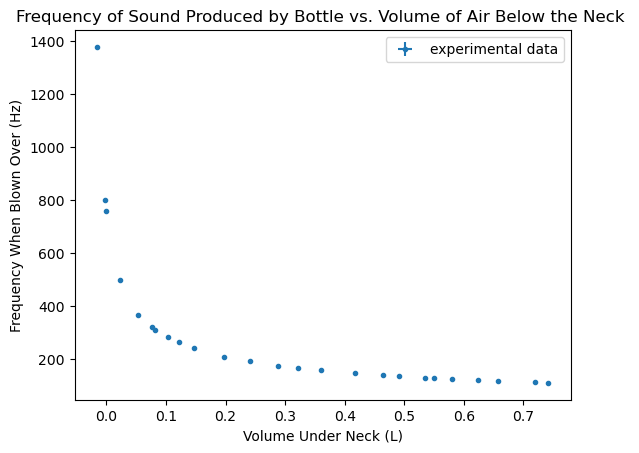

In [15]:
# analyzed_data["volume of air below neck"].pint.to("m^3")

fig, ax = plt.subplots()

units = "L"

ax.errorbar(analyzed_data["volume of air below neck"].pint.to(units).pint.magnitude, analyzed_data["frequency"].pint.magnitude, yerr = frequency_error, xerr=volume_uncertainty_liters, marker='.', label="experimental data", linestyle='None')

plt.legend()

plt.title("Frequency of Sound Produced by Bottle vs. Volume of Air Below the Neck ")
plt.xlabel(f"Volume Under Neck ({units})")
plt.ylabel("Frequency When Blown Over (Hz)")

plt.savefig("figures/data_only.svg")

plt.show()



In [16]:
def model(area_of_opening, volume_under_neck, length_of_neck): 
    output = np.sqrt( (area_of_opening * (speed_of_sound **2)) / (volume_under_neck * length_of_neck ) ) / (2 * np.pi) 

    # print(f"""
    # area_of_opening: {area_of_opening}
    # speed_of_sound: {speed_of_sound}
    # volume_under_neck: {volume_under_neck}
    # length_of_neck: {length_of_neck}
    # output: {output.to("hertz")} # 
    # """)
    

    return output



In [17]:
analyzed_data["volume of air below neck"][3]

<Quantity(0.0006237, 'meter ** 3')>

In [18]:
# model(0.000263022, 0.0006237, 0.0852)

In [19]:
model(area_of_neck, analyzed_data["volume of air below neck"][3], length_of_neck)

<Quantity(1215.25782, 'centimeter ** 0.5 / meter ** 0.5 / second')>

In [20]:
model_data = pd.DataFrame({
    "volume_below_neck" : pd.Series(
        np.linspace(0, max(analyzed_data["volume of air below neck"]), 1000), 
        dtype=analyzed_data["volume of air below neck"].dtype 
    )
})

model_data["predicted_frequency"] = model(area_of_neck, model_data["volume_below_neck"], length_of_neck)

In [21]:
chisq_data = pd.DataFrame()
chisq_data["volume_below_neck"] = analyzed_data["volume of air below neck"].pint.to("m^3")
chisq_data["predicted_frequency"] = model(area_of_neck, chisq_data["volume_below_neck"], length_of_neck)

error = (analyzed_data["frequency"].pint.to("hertz") - chisq_data["predicted_frequency"].pint.to("hertz")).abs()
chisq =  (error ** 2)  / chisq_data["predicted_frequency"].pint.to("hertz")
chisquared = chisq.sum()
chisquared

/opt/anaconda3/lib/python3.12/site-packages/pint/facets/numpy/numpy_func.py:324: RuntimeWarning: invalid value encountered in sqrt
  result_magnitude = func(*stripped_args, **stripped_kwargs)


<Quantity(46.4274892, 'hertz')>

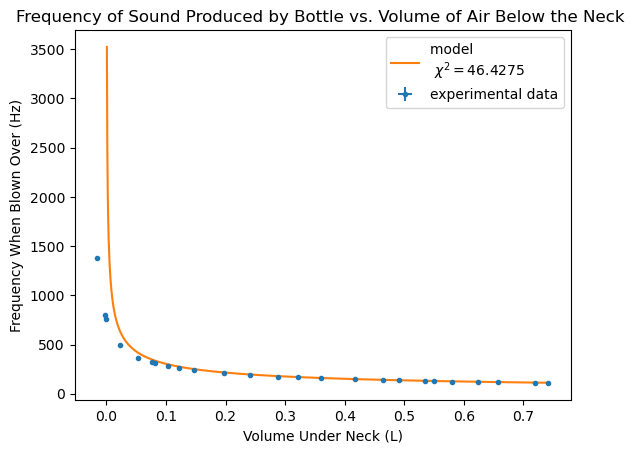

In [22]:
# analyzed_data["volume of air below neck"].pint.to("m^3")

# analyzed_data["volume of air below neck"].pint.to("m^3")

fig, ax = plt.subplots()

units = "L"

ax.errorbar(analyzed_data["volume of air below neck"].pint.to(units).pint.magnitude, analyzed_data["frequency"].pint.magnitude, yerr = frequency_error, xerr=volume_uncertainty_liters, marker='.', label="experimental data", linestyle='None')

ax.plot(model_data["volume_below_neck"].pint.to(units), model_data["predicted_frequency"].pint.to("hertz"), label=f"model \n $\\chi^2={chisquared.magnitude:.4f}$")

# ax.plot(model_data["volume_below_neck"], model_data["predicted_frequency"], label=f"model \n $\\chi^2={chisquared.magnitude:.4f}$",)


plt.legend()

plt.title("Frequency of Sound Produced by Bottle vs. Volume of Air Below the Neck ")
plt.xlabel(f"Volume Under Neck ({units})")
plt.ylabel("Frequency When Blown Over (Hz)")

plt.savefig("figures/data_and_model.svg")

plt.show()




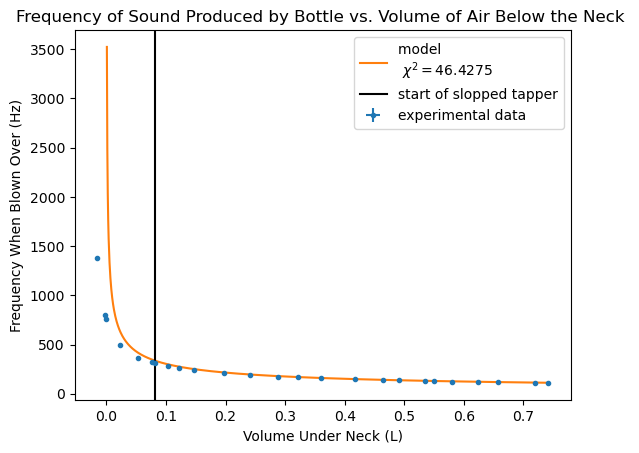

In [23]:

fig, ax = plt.subplots()

units = "L"

# ax.plot(analyzed_data["volume of air below neck"].pint.to(units), analyzed_data["frequency"], marker='o', label="data", linestyle='None')
ax.errorbar(analyzed_data["volume of air below neck"].pint.to(units).pint.magnitude, analyzed_data["frequency"].pint.magnitude, yerr = frequency_error, xerr=volume_uncertainty_liters, marker='.', label="experimental data", linestyle='None')

ax.plot(model_data["volume_below_neck"].pint.to(units), model_data["predicted_frequency"].pint.to("hertz"), label=f"model \n $\\chi^2={chisquared.magnitude:.4f}$")

plt.axvline(analyzed_data["volume of air below neck"][18], label="start of slopped tapper", color="black")

plt.legend()

plt.title("Frequency of Sound Produced by Bottle vs. Volume of Air Below the Neck ")
plt.xlabel(f"Volume Under Neck ({units})")
plt.ylabel("Frequency When Blown Over (Hz)")

plt.savefig("figures/data_and_model_with_line.svg")

plt.show()


In [24]:
analyzed_data["volume of air below neck"][18]
raw_data_set["Notes"][18]

'Start of slopped taper'

In [25]:
chisq_data["predicted_frequency"].pint.to("hertz")

0     111.44027071615686
1       113.209396565982
2     118.36994561063237
3     121.52578242872829
4     125.92315885946562
5     129.36508711944634
6     131.29969306088182
7     136.93898952145383
8     140.91074520574705
9     148.58814059546938
10    159.89105454523263
11    169.39624602099946
12    178.86915918427104
13    195.33841750699023
14     215.6324216074662
15    250.74800454547483
16     274.7744723701549
17     299.0457850662758
18    336.39078898669203
19     346.7703151263804
20    414.54712075051503
21     642.6934390205107
22                   nan
23                   nan
24                   nan
Name: predicted_frequency, dtype: pint[hertz][Float64]

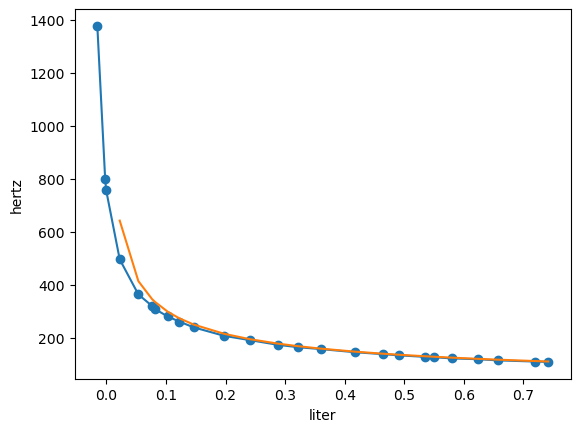

In [26]:
fig, ax = plt.subplots()

ax.plot(analyzed_data["volume of air below neck"].pint.to("L"), analyzed_data["frequency"], marker='o')

ax.plot(chisq_data["volume_below_neck"], chisq_data["predicted_frequency"])

/opt/anaconda3/lib/python3.12/site-packages/pint/facets/numpy/numpy_func.py:324: RuntimeWarning: invalid value encountered in sqrt
  result_magnitude = func(*stripped_args, **stripped_kwargs)


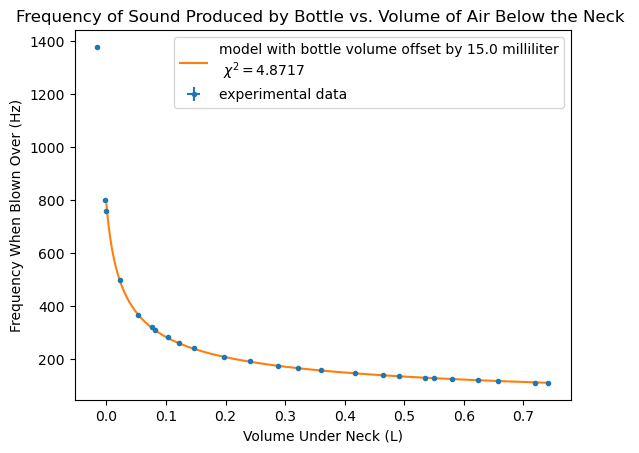

In [27]:

offset = (0.015 * ureg.liters)
new_volume_below_neck = analyzed_data["volume of air below neck"] + offset

length_of_neck_offset = 0

chisq_data = pd.DataFrame()
chisq_data["volume_below_neck"] = new_volume_below_neck.pint.to("m^3")
chisq_data["predicted_frequency"] = model(area_of_neck, new_volume_below_neck.pint.to("m^3"), length_of_neck + length_of_neck_offset)

error = (analyzed_data["frequency"].pint.to("hertz") - chisq_data["predicted_frequency"].pint.to("hertz")).abs()
chisq =  (error ** 2)  / chisq_data["predicted_frequency"].pint.to("hertz")
chisquared = chisq.sum()
chisquared

fig, ax = plt.subplots()

units = "L"

ax.errorbar(analyzed_data["volume of air below neck"].pint.to(units).pint.magnitude, analyzed_data["frequency"].pint.magnitude, yerr = frequency_error, xerr=volume_uncertainty_liters, marker='.', label="experimental data", linestyle='None')

ax.plot(model_data["volume_below_neck"].pint.to(units), model(area_of_neck, model_data["volume_below_neck"] + offset, length_of_neck + length_of_neck_offset).pint.to("hertz"), label=f"model with bottle volume offset by {offset.to("ml")}\n $\\chi^2={chisquared.magnitude:.4f}$")

# ax.plot(model_data["volume_below_neck"], , label="model",)

# plt.axvline(analyzed_data["volume of air below neck"][18], label="start of slopped tapper", color="black")

plt.legend()

plt.title("Frequency of Sound Produced by Bottle vs. Volume of Air Below the Neck ")
plt.xlabel(f"Volume Under Neck ({units})")
plt.ylabel("Frequency When Blown Over (Hz)")

plt.savefig("figures/data_and_model_with_line_offset.svg")

plt.show()


In [28]:
(offset.to("ml") /  area_of_neck).to("mm")

<Quantity(57.029452, 'millimeter')>

In [29]:
length_of_neck_offset.to("mm")

AttributeError: 'int' object has no attribute 'to'

In [ ]:
area_of_neck